# Human Pose / Body Posture Module — Social Cue Analysis for HRI

**Group:** The Unfiltered — Project 6 (Social cue analysis for Human-Robot Interaction)
**This notebook covers:** Ashkan Bazrgary's part — body posture / confidence recognition from body landmarks.

Training data: [Confidence Detection Dataset](https://www.kaggle.com/datasets/muhammadkhubaibahmad/confidence-detection-dataset)
on Kaggle (5,950 rows, 19 landmark-derived features + `confidence_label` target) — self-recording
video clips wasn't feasible (broken webcam + team scheduling), so training uses this public dataset
instead, with a separate MediaPipe extractor built for the eventual live-webcam demo.


## 1. Setup

In [1]:
!pip install -q kaggle mediapipe opencv-python-headless scikit-learn pandas matplotlib joblib

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.5 MB/s eta 0:00:00


## 2. Download the Kaggle dataset

You need a Kaggle API token: Kaggle -> profile -> Account -> "Create New Token" downloads `kaggle.json`.
Upload that file when prompted below (one-time per Colab session).


In [3]:
from google.colab import files

print('Upload your kaggle.json (Kaggle -> Account -> Create New Token):')
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Upload your kaggle.json (Kaggle -> Account -> Create New Token):


Saving kaggle.json to kaggle.json


In [5]:
!kaggle datasets download -d muhammadkhubaibahmad/confidence-detection-dataset -p /content/confidence_data --unzip

DATA_DIR = '/content/confidence_data'
for root, dirs, fnames in os.walk(DATA_DIR):
    for fn in fnames:
        print(os.path.join(root, fn))


Dataset URL: https://www.kaggle.com/datasets/muhammadkhubaibahmad/confidence-detection-dataset
License(s): CC-BY-SA-4.0
100% 779k/779k [00:00<00:00, 122MB/s]

/content/confidence_data/confidence_features.csv


## 3. Inspect the data

Confirmed from the dataset page: `confidence_dataset.csv`, 5,950 rows, 19 features + target
`confidence_label`. Features are ratios/angles/distances computed from pose landmarks (the same
kind of engineering as our own `extract_features()` in section 6). Three columns are categorical:
`head_direction`, `arm_position`, `posture` — encoded in section 4, not dropped.


In [6]:
csv_paths = glob.glob(os.path.join(DATA_DIR, '**', '*.csv'), recursive=True)
print('CSV files found:', csv_paths)

dfs = {p: pd.read_csv(p) for p in csv_paths}
for p, d in dfs.items():
    print('\n===', p, '===')
    print('shape:', d.shape)
    print('columns:', list(d.columns))
    print(d.head(3))


CSV files found: ['/content/confidence_data/confidence_features.csv']

=== /content/confidence_data/confidence_features.csv ===
shape: (5949, 19)
columns: ['eye_shoulder_y_ratio', 'shoulder_y_diff', 'wrist_distance_x', 'wrist_shoulder_ratio', 'nose_eye_center_offset_x', 'shoulder_span', 'hip_shoulder_y_diff', 'body_lean_x', 'shoulder_center_x', 'hip_center_x', 'spine_angle', 'eye_distance', 'head_tilt_angle', 'eye_distance_ratio', 'shoulder_slope', 'head_direction', 'arm_position', 'posture', 'confidence_label']
   eye_shoulder_y_ratio  shoulder_y_diff  wrist_distance_x  \
0             -0.503596         0.007476          0.579019   
1             -0.483258         0.008997          0.569416   
2             -0.499847         0.007365          0.565545   

   wrist_shoulder_ratio  nose_eye_center_offset_x  shoulder_span  \
0              1.265216                  0.005173       0.457695   
1              1.252966                  0.005959       0.454533   
2              1.241425      

In [7]:
# confirmed from the dataset page; double check against the printed columns above
MAIN_CSV = csv_paths[0]
LABEL_COL = 'confidence_label'
CATEGORICAL_COLS = ['head_direction', 'arm_position', 'posture']

df = dfs[MAIN_CSV]
print(df[LABEL_COL].value_counts())
print('\nnull counts:\n', df.isnull().sum())


confidence_label
Confident    3132
Neutral      1662
Low          1155
Name: count, dtype: int64

null counts:
 eye_shoulder_y_ratio        0
shoulder_y_diff             0
wrist_distance_x            0
wrist_shoulder_ratio        0
nose_eye_center_offset_x    0
shoulder_span               0
hip_shoulder_y_diff         0
body_lean_x                 0
shoulder_center_x           0
hip_center_x                0
spine_angle                 0
eye_distance                0
head_tilt_angle             0
eye_distance_ratio          0
shoulder_slope              0
head_direction              0
arm_position                0
posture                     0
confidence_label            0
dtype: int64


## 4. Feature preparation

Numeric columns are used directly; the three categorical columns are one-hot encoded rather than
dropped, since they're part of the dataset's actual signal (not just numeric landmark ratios).


In [8]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != LABEL_COL]
present_cat_cols = [c for c in CATEGORICAL_COLS if c in df.columns]

X_numeric = df[numeric_cols].fillna(0)
X_categorical = pd.get_dummies(df[present_cat_cols].astype(str)) if present_cat_cols else pd.DataFrame(index=df.index)
X = pd.concat([X_numeric, X_categorical], axis=1)
feature_cols = list(X.columns)
print('Using', len(feature_cols), 'feature columns (', len(numeric_cols), 'numeric +',
      X_categorical.shape[1], 'one-hot from', present_cat_cols, ')')

le = LabelEncoder()
y = le.fit_transform(df[LABEL_COL])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


Using 25 feature columns ( 15 numeric + 10 one-hot from ['head_direction', 'arm_position', 'posture'] )


## 5. Train and evaluate

Cross-validation on the training split (not just a single train/test accuracy number) to get a more
honest estimate, matching the brief's ask for a "suitable evaluation for the algorithms implemented".


In [9]:
clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)

cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
print('5-fold CV accuracy: %.3f +/- %.3f' % (cv_scores.mean(), cv_scores.std()))

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('\nHeld-out test accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))


5-fold CV accuracy: 0.948 +/- 0.006

Held-out test accuracy: 0.9549731182795699
              precision    recall  f1-score   support

   Confident       0.92      1.00      0.96       783
         Low       1.00      0.98      0.99       289
     Neutral       0.99      0.85      0.92       416

    accuracy                           0.95      1488
   macro avg       0.97      0.94      0.96      1488
weighted avg       0.96      0.95      0.95      1488



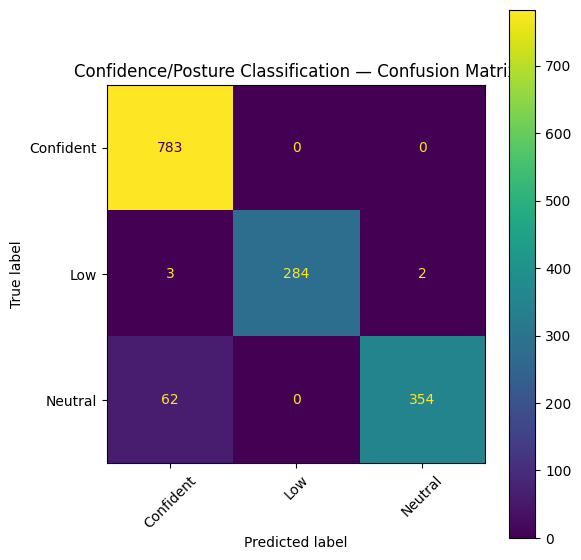

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Confidence/Posture Classification — Confusion Matrix')
plt.tight_layout()
plt.savefig('posture_confusion_matrix.png', dpi=150)
plt.show()
files.download('posture_confusion_matrix.png')


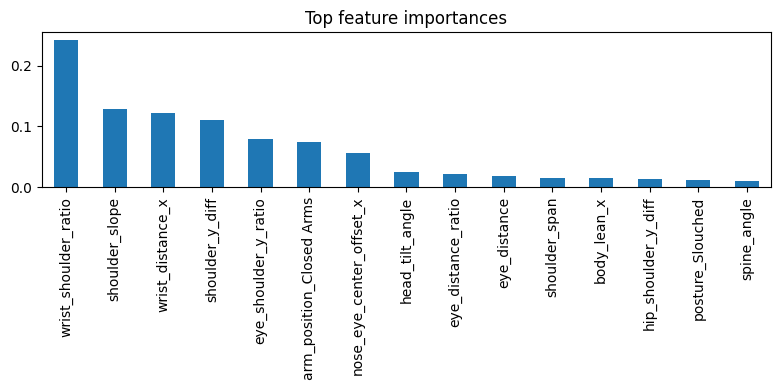

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
importances.plot(kind='bar', figsize=(8, 4), title='Top feature importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
files.download('feature_importance.png')


## 6. Save the trained model

In [13]:
import joblib
joblib.dump({'model': clf, 'label_encoder': le, 'feature_cols': feature_cols}, 'posture_classifier.pkl')
files.download('posture_classifier.pkl')
print('Saved posture_classifier.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved posture_classifier.pkl


## 7. MediaPipe feature extractor (for the live webcam demo)

This dataset's own features are already extracted, so this section is independent of the training
above. Before wiring this into the live demo, verify these formulas actually reproduce the dataset's
own feature values on a few known rows/images — that reconciliation is real, necessary work, not a
given, since the exact formulas the dataset used aren't published.


In [ ]:
!pip install -q mediapipe==0.10.21  # 0.10.31+ dropped mp.solutions on Python 3.12/Colab, see google-ai-edge/mediapipe#6192

In [20]:
import cv2
import mediapipe as mp

mp_pose = mp.solutions.pose


def _mid(a, b):
    return np.array([(a.x + b.x) / 2, (a.y + b.y) / 2, (a.z + b.z) / 2])


def extract_features(landmarks_img, landmarks_world):
    """landmarks_img: pose_landmarks (normalized image coords, x/y in [0,1])
    landmarks_world: pose_world_landmarks (metric 3D, hip-centered)
    Returns a dict of interpretable posture features for a single frame.
    """
    lm = landmarks_img.landmark
    wl = landmarks_world.landmark

    l_sh, r_sh = lm[11], lm[12]
    l_hip, r_hip = lm[23], lm[24]
    l_wr, r_wr = lm[15], lm[16]
    nose = lm[0]

    shoulder_mid = _mid(l_sh, r_sh)
    hip_mid = _mid(l_hip, r_hip)
    shoulder_width = np.linalg.norm(
        np.array([l_sh.x, l_sh.y]) - np.array([r_sh.x, r_sh.y])
    ) + 1e-6

    wrist_dist = np.linalg.norm(
        np.array([l_wr.x, l_wr.y]) - np.array([r_wr.x, r_wr.y])
    )
    openness_score = wrist_dist / shoulder_width

    cross_l = np.linalg.norm(np.array([l_wr.x, l_wr.y]) - np.array([r_sh.x, r_sh.y]))
    cross_r = np.linalg.norm(np.array([r_wr.x, r_wr.y]) - np.array([l_sh.x, l_sh.y]))
    arm_cross_score = min(cross_l, cross_r) / shoulder_width

    head_tilt = (nose.x - shoulder_mid[0]) / shoulder_width

    w_sh_mid_z = (wl[11].z + wl[12].z) / 2
    w_hip_mid_z = (wl[23].z + wl[24].z) / 2
    forward_lean = w_hip_mid_z - w_sh_mid_z

    torso_dx = shoulder_mid[0] - hip_mid[0]
    torso_dy = shoulder_mid[1] - hip_mid[1] + 1e-6
    torso_tilt_angle = np.degrees(np.arctan2(torso_dx, -torso_dy))

    return {
        'openness_score': openness_score,
        'arm_cross_score': arm_cross_score,
        'head_tilt': head_tilt,
        'forward_lean': forward_lean,
        'torso_tilt_angle': torso_tilt_angle,
    }


def process_video(path, pose, sample_every=3):
    """Runs MediaPipe Pose over a video, returns a list of per-frame feature dicts."""
    cap = cv2.VideoCapture(path)
    rows = []
    frame_idx = 0
    while cap.isOpened():
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx % sample_every == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = pose.process(rgb)
            if result.pose_landmarks and result.pose_world_landmarks:
                feats = extract_features(result.pose_landmarks, result.pose_world_landmarks)
                rows.append(feats)
        frame_idx += 1
    cap.release()
    return rows

AttributeError: module 'mediapipe' has no attribute 'solutions'

## Notes / next steps
- Dataset source: Kaggle "Confidence Detection Dataset" — cite this explicitly in the report as the
  training data source, and document why self-recording wasn't feasible.
- TODO (real work, not yet done): verify `extract_features()` reproduces the dataset's own feature
  values on a few sample rows/images before trusting it for live inference.
- TODO: combine this posture/confidence signal with the facial-emotion output (teammate's model)
  into one combined social-cue signal for the response-generation part of the pipeline.
- TODO: try at least one more model (XGBoost or a small MLP) alongside RandomForest for comparison,
  per the brief's ask for "a good range of suggestions and reasoned discussion".
